# VPP三阶段优化结果可视化分析

本Notebook用于可视化分析虚拟电厂(VPP)的三阶段优化结果:
1. **日前计划** (max_profit_1)
2. **日内修正** (max_profit_t)
3. **实时分配** (fast_control_implement)

包括:
- 投标策略对比
- 功率平衡分析
- 利润对比
- 资源类型分析(PV/ES/EV)

In [1]:
# 导入必要的库
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
import matplotlib
import platform
from matplotlib import font_manager
import warnings
warnings.filterwarnings('ignore')

# ========== 设置中文字体 ==========
system = platform.system()
print(f"检测到系统: {system}")

# 查找可用的中文字体
def find_chinese_font():
    """查找系统可用的中文字体"""
    chinese_fonts = [
        'Microsoft YaHei',  # 微软雅黑
        'SimHei',           # 黑体
        'SimSun',           # 宋体
        'KaiTi',           # 楷体
        'FangSong',         # 仿宋
        'STHeiti',          # 华文黑体
        'STSong',           # 华文宋体
        'STKaiti',          # 华文楷体
        'PingFang SC',      # 苹方(简体中文)
        'Heiti SC',         # 黑体-简
        'Arial Unicode MS',  # Arial Unicode(支持中文)
        'Noto Sans CJK SC', # Noto无衬线中文简体
        'WenQuanYi Micro Hei',  # 文泉驿微米黑
    ]
    
    available_fonts = [f.name for f in font_manager.fontManager.ttflist]
    
    # 优先查找中文字体
    for font in chinese_fonts:
        if font in available_fonts:
            print(f"找到中文字体: {font}")
            return font
    
    # 如果没有找到中文字体,返回第一个可用字体
    if available_fonts:
        print(f"未找到中文字体,使用: {available_fonts[0]}")
        return available_fonts[0]
    
    return 'sans-serif'

# 设置字体
chinese_font = find_chinese_font()
matplotlib.rcParams['font.sans-serif'] = [chinese_font]
matplotlib.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题
matplotlib.rcParams['font.family'] = 'sans-serif'

# ========== 设置样式 ==========
try:
    plt.style.use('seaborn-v0_8-darkgrid')
    print("使用样式: seaborn-v0_8-darkgrid")
except:
    try:
        plt.style.use('seaborn-darkgrid')
        print("使用样式: seaborn-darkgrid")
    except:
        plt.style.use('default')
        print("使用样式: default")

# ========== 重新设置字体（必须在样式设置之后）==========
matplotlib.rcParams['font.sans-serif'] = [chinese_font]
matplotlib.rcParams['axes.unicode_minus'] = False
matplotlib.rcParams['font.family'] = 'sans-serif'
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

# ========== 设置图形参数 ==========
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['savefig.bbox'] = 'tight'
plt.rcParams['savefig.format'] = 'png'

print(f"当前字体: {matplotlib.rcParams['font.sans-serif'][0]}")
print("库导入完成!\n")

检测到系统: Windows
找到中文字体: Microsoft YaHei
使用样式: seaborn-v0_8-darkgrid
当前字体: Microsoft YaHei
库导入完成!



## 1. 加载仿真结果

In [2]:
# 查找最新的结果文件
results_dir = 'results'
result_files = [f for f in os.listdir(results_dir) if f.startswith('vpp_results_') and f.endswith('.csv')]
result_files.sort(reverse=True)

if result_files:
    latest_file = result_files[0]
    print(f"找到最新的结果文件: results\{latest_file}")
    df = pd.read_csv(os.path.join(results_dir, latest_file))
    print("数据加载成功!")
else:
    print("未找到结果文件!")
    df = None

if df is not None:
    print(f"时间段数: {len(df)}")
    print(f"数据列数: {len(df.columns)}")
    print(f"数据列: {df.columns.tolist()}")
    print()

找到最新的结果文件: results\vpp_results_20260301_203845.csv
数据加载成功!
时间段数: 24
数据列数: 17
数据列: ['时段', '日前基础功率', '日前调频功率', '修正后基础功率', '修正后调频功率', '日前利润', '实际利润', '日前能量费用', '日前容量收益', '日前里程收益', '实际能量费用', '实际容量收益', '实际里程收益', '实际里程', '实际能量', '实际成本', '修正次数']



## 2. 投标策略对比

✓ 投标策略对比图已保存


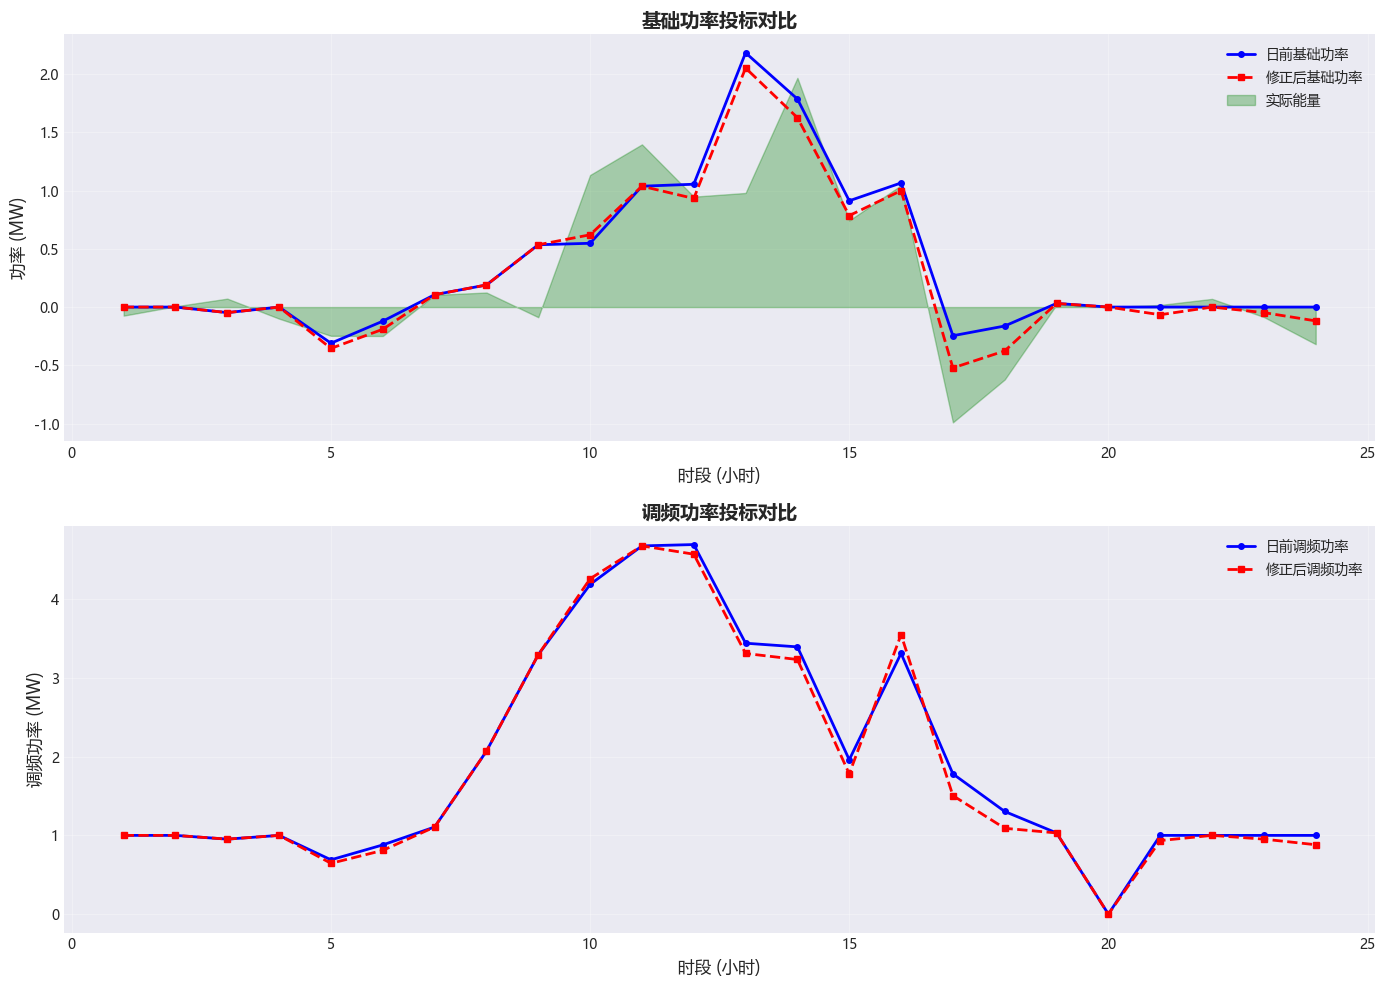

In [3]:
if df is not None:
    fig, axes = plt.subplots(2, 1, figsize=(14, 10))
    slots = df['时段']
    
    # 子图1: 基础功率投标
    axes[0].plot(slots, df['日前基础功率'], 'b-', label='日前基础功率', linewidth=2, marker='o', markersize=4)
    axes[0].plot(slots, df['修正后基础功率'], 'r--', label='修正后基础功率', linewidth=2, marker='s', markersize=4)
    axes[0].fill_between(slots, df['实际能量'], alpha=0.3, label='实际能量', color='green')
    axes[0].set_xlabel('时段 (小时)', fontsize=12)
    axes[0].set_ylabel('功率 (MW)', fontsize=12)
    axes[0].set_title('基础功率投标对比', fontsize=14, fontweight='bold')
    axes[0].legend(fontsize=10)
    axes[0].grid(True, alpha=0.3)
    
    # 子图2: 调频功率投标
    axes[1].plot(slots, df['日前调频功率'], 'b-', label='日前调频功率', linewidth=2, marker='o', markersize=4)
    axes[1].plot(slots, df['修正后调频功率'], 'r--', label='修正后调频功率', linewidth=2, marker='s', markersize=4)
    axes[1].set_xlabel('时段 (小时)', fontsize=12)
    axes[1].set_ylabel('调频功率 (MW)', fontsize=12)
    axes[1].set_title('调频功率投标对比', fontsize=14, fontweight='bold')
    axes[1].legend(fontsize=10)
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('bidding_comparison.png')
    print("✓ 投标策略对比图已保存")
    plt.show()

## 3. 利润对比

✓ 利润对比图已保存


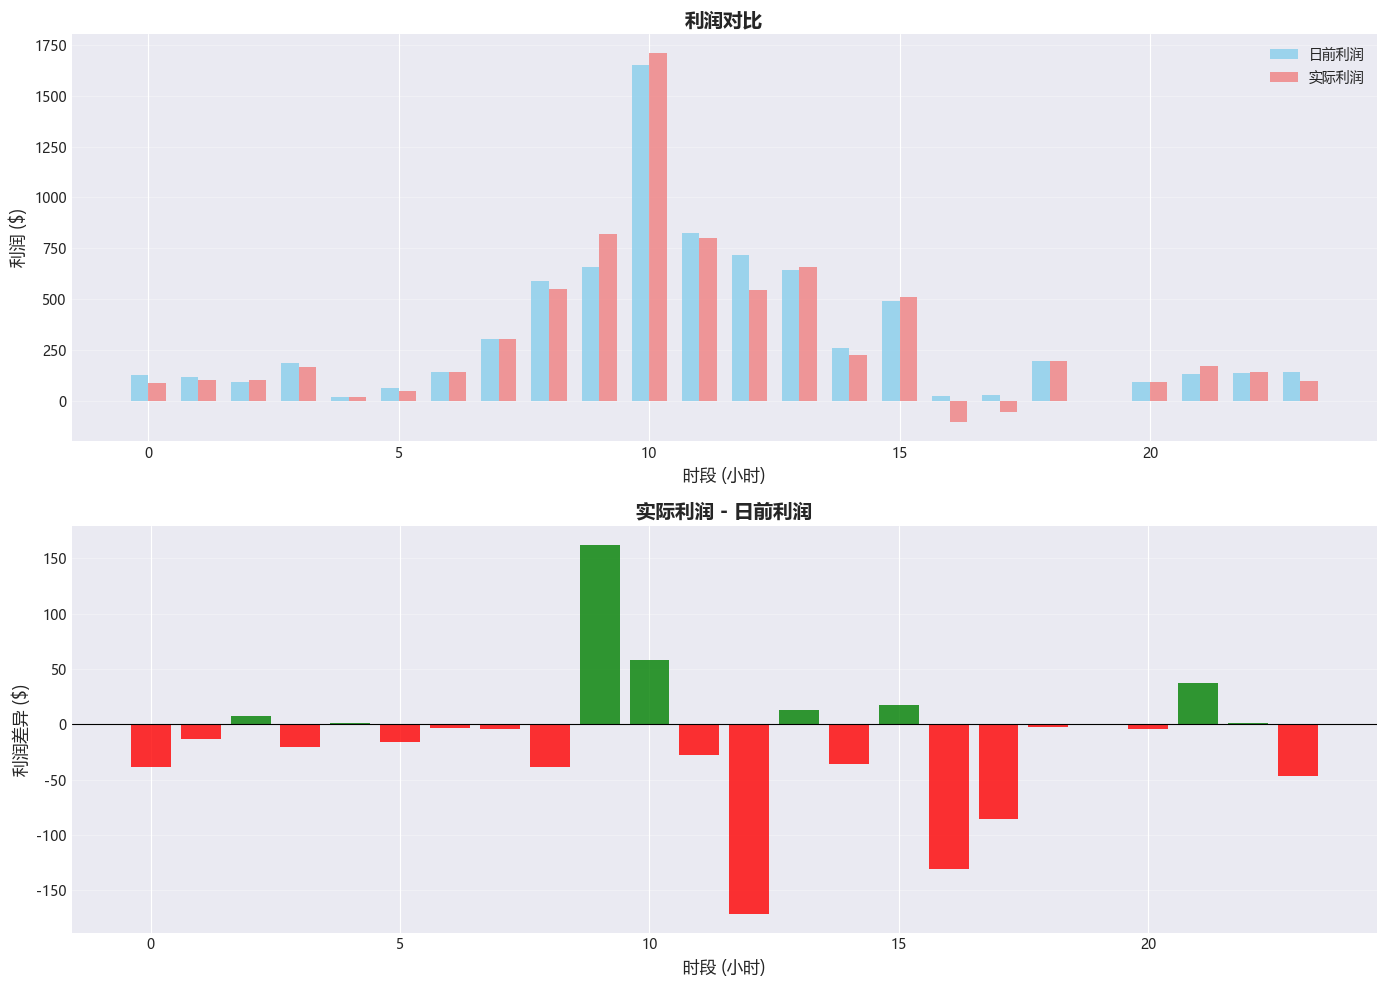

In [4]:
if df is not None:
    fig, axes = plt.subplots(2, 1, figsize=(14, 10))
    
    # 子图1: 利润对比
    width = 0.35
    x = np.arange(len(slots))
    axes[0].bar(x - width/2, df['日前利润'], width, label='日前利润', alpha=0.8, color='skyblue')
    axes[0].bar(x + width/2, df['实际利润'], width, label='实际利润', alpha=0.8, color='lightcoral')
    axes[0].set_xlabel('时段 (小时)', fontsize=12)
    axes[0].set_ylabel('利润 ($)', fontsize=12)
    axes[0].set_title('利润对比', fontsize=14, fontweight='bold')
    axes[0].legend(fontsize=10)
    axes[0].grid(True, alpha=0.3, axis='y')
    
    # 子图2: 利润差异
    profit_diff = df['实际利润'] - df['日前利润']
    colors = ['green' if x >= 0 else 'red' for x in profit_diff]
    axes[1].bar(x, profit_diff, alpha=0.8, color=colors)
    axes[1].axhline(y=0, color='black', linestyle='-', linewidth=0.8)
    axes[1].set_xlabel('时段 (小时)', fontsize=12)
    axes[1].set_ylabel('利润差异 ($)', fontsize=12)
    axes[1].set_title('实际利润 - 日前利润', fontsize=14, fontweight='bold')
    axes[1].grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.savefig('profit_comparison.png')
    print("✓ 利润对比图已保存")
    plt.show()

## 4. 功率平衡分析

✓ 功率平衡图已保存


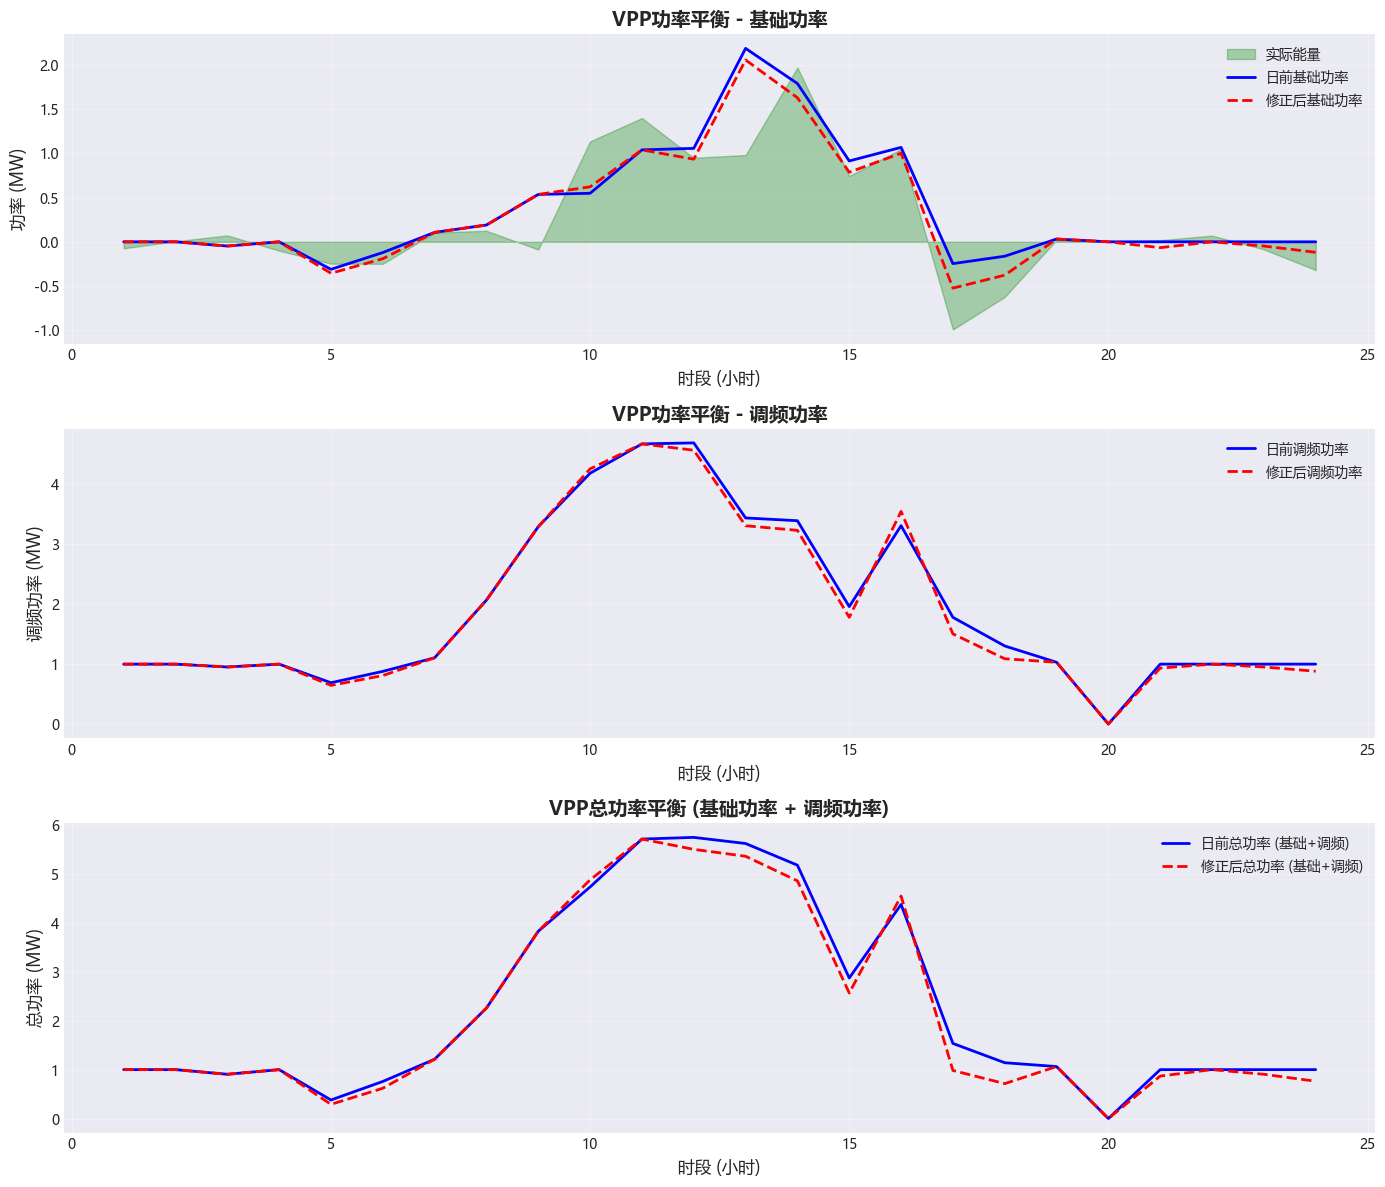

In [5]:
if df is not None:
    fig, axes = plt.subplots(3, 1, figsize=(14, 12))
    
    # 子图1: 基础功率平衡
    axes[0].fill_between(slots, df['实际能量'], alpha=0.3, label='实际能量', color='green')
    axes[0].plot(slots, df['日前基础功率'], 'b-', label='日前基础功率', linewidth=2)
    axes[0].plot(slots, df['修正后基础功率'], 'r--', label='修正后基础功率', linewidth=2)
    axes[0].set_xlabel('时段 (小时)', fontsize=12)
    axes[0].set_ylabel('功率 (MW)', fontsize=12)
    axes[0].set_title('VPP功率平衡 - 基础功率', fontsize=14, fontweight='bold')
    axes[0].legend(fontsize=10)
    axes[0].grid(True, alpha=0.3)
    
    # 子图2: 调频功率平衡
    axes[1].plot(slots, df['日前调频功率'], 'b-', label='日前调频功率', linewidth=2)
    axes[1].plot(slots, df['修正后调频功率'], 'r--', label='修正后调频功率', linewidth=2)
    axes[1].set_xlabel('时段 (小时)', fontsize=12)
    axes[1].set_ylabel('调频功率 (MW)', fontsize=12)
    axes[1].set_title('VPP功率平衡 - 调频功率', fontsize=14, fontweight='bold')
    axes[1].legend(fontsize=10)
    axes[1].grid(True, alpha=0.3)
    
    # 子图3: 总功率平衡 (基础功率 + 调频功率)
    # 计算总功率（基础功率 + 调频功率）
    total_power_day = df['日前基础功率'] + df['日前调频功率']
    total_power_rev = df['修正后基础功率'] + df['修正后调频功率']
    axes[2].plot(slots, total_power_day, 'b-', label='日前总功率 (基础+调频)', linewidth=2)
    axes[2].plot(slots, total_power_rev, 'r--', label='修正后总功率 (基础+调频)', linewidth=2)
    axes[2].set_xlabel('时段 (小时)', fontsize=12)
    axes[2].set_ylabel('总功率 (MW)', fontsize=12)
    axes[2].set_title('VPP总功率平衡 (基础功率 + 调频功率)', fontsize=14, fontweight='bold')
    axes[2].legend(fontsize=10)
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('power_balance.png')
    print("✓ 功率平衡图已保存")
    plt.show()

## 5. 按资源类型分析

In [6]:
# 检查是否有资源级别的结果文件
resource_file = os.path.join(results_dir, latest_file.replace('vpp_results_', 'resource_results_'))
df_resource = None

if os.path.exists(resource_file):
    df_resource = pd.read_csv(resource_file)
    print(f"找到资源级结果文件: {resource_file}")
    print(f"资源数: {len(df_resource)}")
    print(f"资源类型: {df_resource['资源类型'].unique() if '资源类型' in df_resource.columns else '未知'}")
else:
    print("未找到资源级结果文件，跳过资源类型分析")

if df_resource is not None and '资源类型' in df_resource.columns:
    fig, axes = plt.subplots(2, 1, figsize=(14, 10))
    
    colors = {'PV': 'orange', 'ES': 'blue', 'EV': 'green'}
    
    # 子图1: 日前基础功率分配
    for res_type in ['PV', 'ES', 'EV']:
        df_res = df_resource[df_resource['资源类型'] == res_type]
        if len(df_res) > 0:
            axes[0].plot(df_res['时段'], df_res['日前基础功率'], 
                        label=res_type, color=colors[res_type], linewidth=2)
    axes[0].set_xlabel('时段 (小时)', fontsize=11)
    axes[0].set_ylabel('基础功率 (MW)', fontsize=11)
    axes[0].set_title('日前基础功率分配 - 按资源类型', fontsize=12, fontweight='bold')
    axes[0].legend(fontsize=10)
    axes[0].grid(True, alpha=0.3)
    
    # 子图2: 日前调频功率分配
    for res_type in ['PV', 'ES', 'EV']:
        df_res = df_resource[df_resource['资源类型'] == res_type]
        if len(df_res) > 0:
            axes[1].plot(df_res['时段'], df_res['日前调频功率'], 
                        label=res_type, color=colors[res_type], linewidth=2)
    axes[1].set_xlabel('时段 (小时)', fontsize=11)
    axes[1].set_ylabel('调频功率 (MW)', fontsize=11)
    axes[1].set_title('日前调频功率分配 - 按资源类型', fontsize=12, fontweight='bold')
    axes[1].legend(fontsize=10)
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('resource_type_analysis.png')
    print("✓ 资源类型分析图已保存")
    plt.show()

未找到资源级结果文件，跳过资源类型分析


## 7. 总结统计

In [8]:
if df is not None:
    print("="*50)
    print("VPP三阶段优化结果总结")
    print("="*50)
    print(f"\n总日前利润: ${df['日前利润'].sum():.2f}")
    print(f"总实际利润: ${df['实际利润'].sum():.2f}")
    print(f"利润差异: ${df['实际利润'].sum() - df['日前利润'].sum():.2f}")
    print(f"\n总实际里程: {df['实际里程'].sum():.2f} MW")
    print(f"总实际能量: {df['实际能量'].sum():.2f} MWh")
    print(f"总修正次数: {int(df['修正次数'].sum())}")
    print(f"\n平均日前基础功率: {df['日前基础功率'].mean():.4f} MW")
    print(f"平均日前调频功率: {df['日前调频功率'].mean():.4f} MW")
    print(f"平均修正后调频功率: {df['修正后调频功率'].mean():.4f} MW")
    print("="*50)

VPP三阶段优化结果总结

总日前利润: $7677.58
总实际利润: $7338.87
利润差异: $-338.71

总实际里程: 1187.26 MW
总实际能量: 5.86 MWh
总修正次数: 0

平均日前基础功率: 0.3567 MW
平均日前调频功率: 1.9074 MW
平均修正后调频功率: 1.8608 MW
